# Survey weights and sensitivity: the Horvitz–Thompson estimator

[`survey_pipeline_invariants.ipynb`](survey_pipeline_invariants.ipynb) noted
in passing that "for equal-probability designs the sensitivity of the
Horvitz–Thompson estimator is the same as for the unweighted estimator" —
and left the unequal-probability case for later. This is that later:
Drechsler & Bailie's Section 4, on what survey weights do to sensitivity
once they stop being constant.

Statistical agencies almost never release *unweighted* survey statistics —
unequal probabilities of selection make unweighted means and totals biased,
so agencies weight each observation by (roughly) the inverse of its
selection probability. The classical estimator is Horvitz & Thompson
(1952)'s: for a population of size `N` and sample weights `w_i`,

```
mu_hat_HT = sum(w_i * y_i) / N
```

If the weights can be treated as fixed public numbers, the sensitivity of
this statistic — the maximum amount one record's value can move it — is
`max(w_i) * R / N`, where `R` is the range of `y`. Equal-probability designs
have `w_i = N/n` for everyone, so this reduces to the familiar `R/n`. Once
weights vary, `max(w_i)` can be *much* larger than the average weight — and
that's what drives the noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import opendp.prelude as dp

dp.enable_features("contrib", "honest-but-curious")

from noisyvalue import opendp as nvdp
from noisyvalue import plot_posterior

## A frame with a skewed measure of size

`N = 1000` units, each with a measure-of-size variable `x` (say, a
business's revenue, used to size the sample) and an outcome `y` bounded to
`[0, 1]`, mildly correlated with `x`. Two sampling designs draw `n ~ 100`:

- **SRS**: every unit equally likely, weight `w_i = N/n` for everyone.
- **PPS** (probability proportional to size): inclusion probability
  `pi_i = n * x_i / sum(x)`, weight `w_i = 1/pi_i` — this is the design an
  agency would actually use here, since it puts big, informative units in
  the sample far more often than SRS would.

In [2]:
rng = np.random.default_rng(0)

N, n, R = 1000, 100, 1.0
x = rng.gamma(shape=2.0, scale=1.0, size=N) + 0.1
y_frame = np.clip(0.3 + 0.15 * (x - x.mean()) + rng.normal(0, 0.3, N), 0.0, 1.0)
true_total = y_frame.sum()

srs_idx = rng.choice(N, size=n, replace=False)
w_srs = N / n
terms_srs = (np.full(n, w_srs) * y_frame[srs_idx]).tolist()

pi = np.clip(n * x / x.sum(), 1e-6, 0.999)   # Poisson PPS, expected sample size n
included = rng.random(N) < pi
w_full = 1.0 / pi                             # every frame member's weight, were they sampled
terms_pps = (w_full[included] * y_frame[included]).tolist()

print(f"true population total: {true_total:.1f}")
print(f"SRS sample size {n}, weight {w_srs:.1f} for everyone")
print(f"PPS sample size {included.sum()}, weights range "
      f"[{w_full[included].min():.1f}, {w_full[included].max():.1f}]")

true population total: 319.5
SRS sample size 100, weight 10.0 for everyone
PPS sample size 103, weights range [2.4, 40.1]


## Sensitivity: `max(w_i)` over the *frame*, not just the sample

The bound isn't `max` over whoever happened to be sampled this time — a
`+1`/`-1` neighbor could swap in any frame member, including one that
wasn't drawn but would have carried a very large weight had it been. That's
`w_full.max()`, not `w_full[included].max()`.

In [3]:
sens_srs = w_srs * R
sens_pps = w_full.max() * R   # worst case over the whole frame, not just who was sampled

print(f"SRS sensitivity: {sens_srs:.1f}")
print(f"PPS sensitivity: {sens_pps:.1f}  ({sens_pps / sens_srs:.0f}x larger than SRS)")

SRS sensitivity: 10.0
PPS sensitivity: 176.3  (18x larger than SRS)


## Releasing both, through the library

Same pattern as before: a bounded `make_sum` over the weighted terms,
chained with `nvdp.make_gaussian`. The only thing that changes between
designs is which sensitivity we declare.

SRS: released ~304.3326900590219, noise scale 10.0
PPS: released ~326.83452993259334, noise scale 176.3


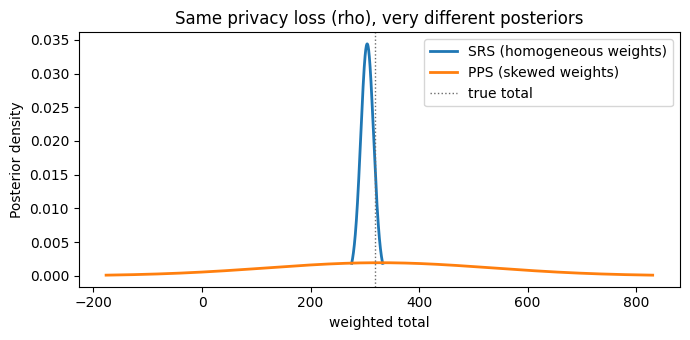

In [4]:
def release_weighted_total(terms, sensitivity, rho=0.5):
    trans = dp.t.make_sum(
        dp.vector_domain(dp.atom_domain(bounds=(0.0, sensitivity), nan=False)),
        dp.symmetric_distance())
    scale = np.sqrt(sensitivity ** 2 / (2 * rho))   # rho-zCDP calibration for Gaussian noise
    meas = trans >> nvdp.make_gaussian(trans.output_domain, trans.output_metric, scale)
    return meas(terms), scale

value_srs, scale_srs = release_weighted_total(terms_srs, sens_srs)
value_pps, scale_pps = release_weighted_total(terms_pps, sens_pps)

print(f"SRS: released {value_srs}, noise scale {scale_srs:.1f}")
print(f"PPS: released {value_pps}, noise scale {scale_pps:.1f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_posterior(value_srs, value_pps, ax=ax)
ax.axvline(true_total, color="#6b6b6b", linewidth=1, linestyle=":", label="true total")
ax.legend(["SRS (homogeneous weights)", "PPS (skewed weights)", "true total"])
ax.set_title("Same privacy loss (rho), very different posteriors")
ax.set_xlabel("weighted total")
plt.tight_layout()

Faithfully honoring the PPS design weights costs a great deal of accuracy
for the same privacy budget — the single frame member with the smallest
inclusion probability sets the sensitivity for everyone, even though most
sampled units carry far smaller weights. This is exactly the tension the
paper flags: ignoring the design (releasing the biased unweighted estimator
instead) is cheap in noise but wrong in expectation; releasing the correct
Horvitz–Thompson estimator is unbiased but can be very noisy.

## The middle ground: regularize the weights

Seeman, Si & Reiter (2024) propose capping weights at some threshold before
computing the estimator — trading a little design bias for a lot less
sensitivity. Capped weight `w_i' = min(w_i, cap)` bounds the sensitivity at
`cap * R`, independent of how extreme the true design weights get.

Capping introduces bias (units with very small inclusion probabilities are
now under-weighted), but if the privacy noise saved outweighs the bias
introduced, the *total* error can still go down. We sweep the cap from
tight (close to the SRS weight) to loose (the true PPS maximum, i.e. no
regularization at all) and, at each cap, estimate both components of error
by repeatedly redrawing the PPS sample:

In [5]:
rho = 0.5
caps = np.geomspace(w_srs, w_full.max(), 10)
M = 3000

records = []
for cap in caps:
    w_capped = np.minimum(w_full, cap)
    sensitivity = cap * R
    noise_var = sensitivity ** 2 / (2 * rho)

    estimates = np.empty(M)
    for m in range(M):
        draw = rng.random(N) < pi
        estimates[m] = (w_capped[draw] * y_frame[draw]).sum()

    bias = estimates.mean() - true_total
    sampling_var = estimates.var()
    rmse = np.sqrt(sampling_var + bias ** 2 + noise_var)
    records.append((cap, bias, np.sqrt(sampling_var), np.sqrt(noise_var), rmse))

caps_arr, bias_arr, samp_sd_arr, noise_sd_arr, rmse_arr = map(np.array, zip(*records))
best = caps_arr[np.argmin(rmse_arr)]
print(f"cap that minimizes total RMSE: {best:.1f} "
      f"(uncapped would be {w_full.max():.1f})")

cap that minimizes total RMSE: 18.9 (uncapped would be 176.3)


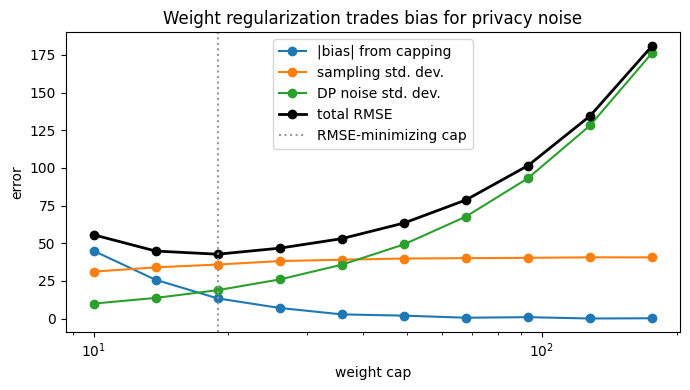

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(caps_arr, np.abs(bias_arr), "o-", label="|bias| from capping")
ax.plot(caps_arr, samp_sd_arr, "o-", label="sampling std. dev.")
ax.plot(caps_arr, noise_sd_arr, "o-", label="DP noise std. dev.")
ax.plot(caps_arr, rmse_arr, "o-", color="black", linewidth=2, label="total RMSE")
ax.axvline(best, color="0.6", linestyle=":", label="RMSE-minimizing cap")
ax.set_xscale("log")
ax.set_xlabel("weight cap")
ax.set_ylabel("error")
ax.set_title("Weight regularization trades bias for privacy noise")
ax.legend()
plt.tight_layout()

Total error is U-shaped: capping too aggressively biases the estimator away
from the true total (units with small inclusion probability get
systematically under-counted); not capping at all forces enough noise to
swamp the signal. The minimum sits well below the uncapped sensitivity — a
concrete instance of the "extreme version of this strategy would set all
weights to be equal" comment in the paper, landing somewhere well short of
that extreme.

## The same release, via the `polars` `Context`

Everything above also goes through the declarative `Context`/`release_query`
layer from
[`opendp_polars.ipynb`](opendp_polars.ipynb) — the weighted column is just
another column, and the sensitivity is just the bounds passed to `.dp.sum`:

In [7]:
import polars as pl

pps_frame = pl.LazyFrame({"weighted_y": w_full[included] * y_frame[included]})

ctx = dp.Context.compositor(
    data=pps_frame,
    privacy_unit=dp.unit_of(contributions=1),
    privacy_loss=dp.loss_of(rho=rho),
    split_evenly_over=1,
    margins=[dp.polars.Margin(by=[], max_length=N, max_groups=1)])

query = ctx.query().select(pl.col("weighted_y").dp.sum((0.0, sens_pps)))
query.summarize()

column,aggregate,distribution,scale
str,str,str,f64
"""weighted_y""","""Sum""","""Float Gaussian""",176.335


In [8]:
release = nvdp.release_query(query)
release.frame

,weighted_y
0,~74.49112364516517
